In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns

df = pd.read_csv("data/train.csv")

In [2]:
df

,id,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,Designation,MonthlyIncome,customer_info,ProdTaken
0,0,50歳,Self Enquiry,2,900秒,Large Business,male,1.0,4.0,Basic,3.0,5,1,4,Executive,253905.0,未婚 車未所持 子供なし,1
1,1,56歳,Company Invited,1,14分,Salaried,Male,1.0,4.0,Standard,3.0,2,1,4,Senior Manager,404475.0,"離婚済み,車あり,子供無し",0
2,2,NaN,Self Enquiry,1,10分,Large Business,Female,1.0,3.0,Basic,3.0,4,0,4,Executive,278145.0,"結婚済み、自動車未所有,子供なし",1
3,3,三十七歳,Self Enquiry,2,1080秒,Small Business,female,1.0,3.0,Standard,4.0,1,0,5,Senior Manager,326805.0,離婚済み、車所持、子供無し,0
4,4,48歳,Company Invited,3,1020秒,Small Business,female,1.0,3.0,Basic,4.0,4,0,4,Executive,258435.0,独身／車所持／無子,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3484,3484,40歳,Self Enquiry,2,1560秒,Salaried,Male,2.0,3.0,Basic,3.0,3,0,1,Executive,258900.0,離婚済み 乗用車所持 子供なし,1
3485,3485,40代,Self Enquiry,1,9分,Large Business,Male,3.0,3.0,Basic,5.0,5,0,3,Executive,260415.0,結婚済み、車所持、子供2人,0
3486,3486,31歳,Self Enquiry,1,840秒,Small Business,FEMALE,3.0,2.0,Standard,3.0,5,0,4,Senior Manager,317340.0,独身／車所持／こども1人,0
3487,3487,56歳,Company Invited,2,900秒,Salaried,Male,3.0,6.0,King,3.0,7,1,4,VP,527910.0,結婚済み、自動車未所有、子供2人,1


# 顧客の情報のメモ(婚姻状況や車の有無、旅行への子どもの同伴の有無)

# データ整理

In [20]:
df["customer_info"] = df["customer_info"].fillna("")

In [21]:
df["customer_info"]

0           [未婚, 車未所持, 子供なし]
1          [離婚済み, 車あり, 子供無し]
2       [結婚済み, 自動車未所有, 子供なし]
3          [離婚済み, 車所持, 子供無し]
4              [独身, 車所持, 無子]
                ...         
3484     [離婚済み, 乗用車所持, 子供なし]
3485       [結婚済み, 車所持, 子供2人]
3486        [独身, 車所持, こども1人]
3487    [結婚済み, 自動車未所有, 子供2人]
3488      [結婚済み, 車未所持, 子供1人]
Name: customer_info, Length: 3489, dtype: object

In [4]:
df["customer_info"] = df["customer_info"].str.replace(r'[、,／/]+|\s+', ' ', regex=True)
df["customer_info"] = df["customer_info"].str.strip()
df["customer_info"]

0           未婚 車未所持 子供なし
1          離婚済み 車あり 子供無し
2       結婚済み 自動車未所有 子供なし
3          離婚済み 車所持 子供無し
4              独身 車所持 無子
              ...       
3484     離婚済み 乗用車所持 子供なし
3485       結婚済み 車所持 子供2人
3486        独身 車所持 こども1人
3487    結婚済み 自動車未所有 子供2人
3488      結婚済み 車未所持 子供1人
Name: customer_info, Length: 3489, dtype: str

In [5]:
df["customer_info"] = df["customer_info"].str.replace(" ", ",")
df["customer_info"] = df["customer_info"].str.split(",")

In [6]:
df["customer_info"][0]

['未婚', '車未所持', '子供なし']

In [7]:
df["customer_info"][0][0]

'未婚'

# 配偶者"customer_info_marriage"
1:結婚 0:未婚（「結婚」の文字が含まれていれば1）

In [22]:
df["customer_info_marriage"] = df["customer_info"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "")
df["customer_info_marriage"] = df["customer_info_marriage"].apply(lambda x: 1 if "結婚" in str(x) else 0)
df["customer_info_marriage"]

0       0
1       0
2       1
3       0
4       0
       ..
3484    0
3485    1
3486    0
3487    1
3488    1
Name: customer_info_marriage, Length: 3489, dtype: int64

### アンケート全体の割合

In [23]:
print("1:結婚 0:未婚")
df["customer_info_marriage"].value_counts()

1:結婚 0:未婚


customer_info_marriage
0    2105
1    1384
Name: count, dtype: int64

In [24]:
df[["customer_info", "ProdTaken", "customer_info_marriage"]]
# ProdTaken	0:不成約、1:成約

,customer_info,ProdTaken,customer_info_marriage
0,"[未婚, 車未所持, 子供なし]",1,0
1,"[離婚済み, 車あり, 子供無し]",0,0
2,"[結婚済み, 自動車未所有, 子供なし]",1,1
3,"[離婚済み, 車所持, 子供無し]",0,0
4,"[独身, 車所持, 無子]",1,0
...,...,...,...
3484,"[離婚済み, 乗用車所持, 子供なし]",1,0
3485,"[結婚済み, 車所持, 子供2人]",0,1
3486,"[独身, 車所持, こども1人]",0,0
3487,"[結婚済み, 自動車未所有, 子供2人]",1,1


### グラフ
左が未成約、右が成約のグラフ

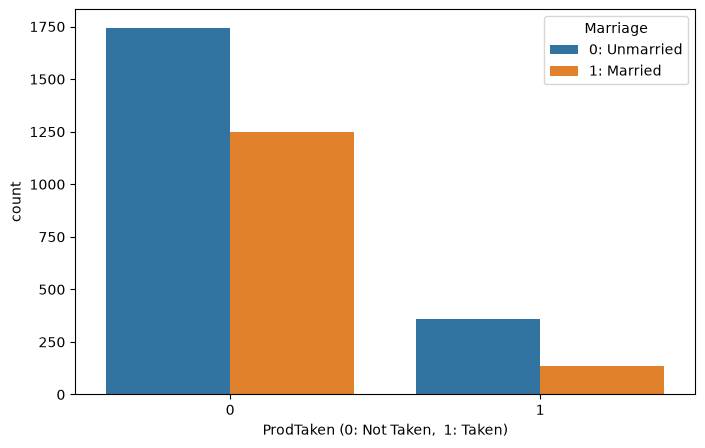

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="ProdTaken", hue="customer_info_marriage")
plt.xlabel("ProdTaken (0: Not Taken,  1: Taken)")
plt.legend(title="Marriage", labels=["0: Unmarried", "1: Married"])

plt.show()

余り関連性はなさそう

# 車を所持しているか"customer_info_usecar"
1:所持 0:未所持（「未」「なし」「無し」が含まれていれば0、それ以外は1）

In [26]:
df["customer_info_usecar"] = df["customer_info"].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else "")
df["customer_info_usecar"] = df["customer_info_usecar"].apply(lambda x: 0 if "未" in str(x) or "なし" in str(x) or "無し" in str(x) else 1)
df["customer_info_usecar"]

0       0
1       1
2       0
3       1
4       1
       ..
3484    1
3485    1
3486    1
3487    0
3488    0
Name: customer_info_usecar, Length: 3489, dtype: int64

### アンケート全体の割合

In [27]:
print("1:所持 0:未所持")
df["customer_info_usecar"].value_counts()

1:所持 0:未所持


customer_info_usecar
0    1785
1    1704
Name: count, dtype: int64

In [28]:
df[["customer_info", "ProdTaken", "customer_info_usecar"]]
# ProdTaken	0:不成約、1:成約

,customer_info,ProdTaken,customer_info_usecar
0,"[未婚, 車未所持, 子供なし]",1,0
1,"[離婚済み, 車あり, 子供無し]",0,1
2,"[結婚済み, 自動車未所有, 子供なし]",1,0
3,"[離婚済み, 車所持, 子供無し]",0,1
4,"[独身, 車所持, 無子]",1,1
...,...,...,...
3484,"[離婚済み, 乗用車所持, 子供なし]",1,1
3485,"[結婚済み, 車所持, 子供2人]",0,1
3486,"[独身, 車所持, こども1人]",0,1
3487,"[結婚済み, 自動車未所有, 子供2人]",1,0


### グラフ
左が未成約、右が成約のグラフ

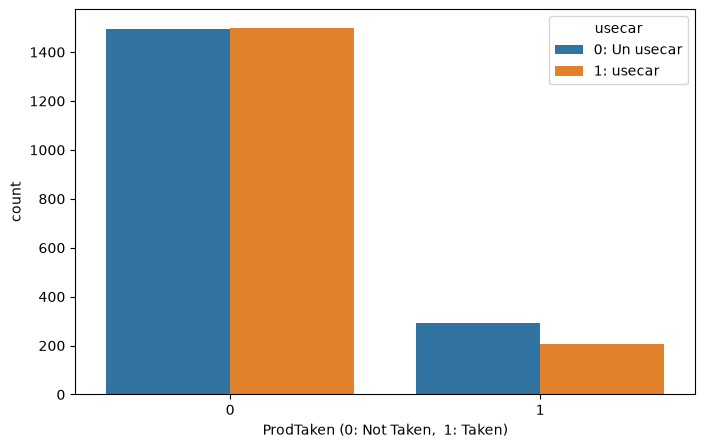

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="ProdTaken", hue="customer_info_usecar")
plt.xlabel("ProdTaken (0: Not Taken,  1: Taken)")
plt.legend(title="usecar", labels=["0: Un usecar", "1: usecar"])

plt.show()

# 子供はいるか"customer_info_child"
1:あり 0:なし（「無」「なし」「ゼロ」が含まれていれば0、それ以外は1）

In [29]:
df["customer_info_child"] = df["customer_info"].apply(lambda x: x[2] if isinstance(x, list) and len(x) > 2 else "")
df["customer_info_child"] = df["customer_info_child"].apply(lambda x: 0 if "無" in str(x) or "なし" in str(x) or "ゼロ" in str(x) else 1)
df["customer_info_child"] 

0       0
1       0
2       0
3       0
4       0
       ..
3484    0
3485    1
3486    1
3487    1
3488    1
Name: customer_info_child, Length: 3489, dtype: int64

### アンケート全体の割合

In [30]:
df[["customer_info", "ProdTaken", "customer_info_child"]]
# ProdTaken	0:不成約、1:成約

,customer_info,ProdTaken,customer_info_child
0,"[未婚, 車未所持, 子供なし]",1,0
1,"[離婚済み, 車あり, 子供無し]",0,0
2,"[結婚済み, 自動車未所有, 子供なし]",1,0
3,"[離婚済み, 車所持, 子供無し]",0,0
4,"[独身, 車所持, 無子]",1,0
...,...,...,...
3484,"[離婚済み, 乗用車所持, 子供なし]",1,0
3485,"[結婚済み, 車所持, 子供2人]",0,1
3486,"[独身, 車所持, こども1人]",0,1
3487,"[結婚済み, 自動車未所有, 子供2人]",1,1


### グラフ
左が未成約、右が成約のグラフ

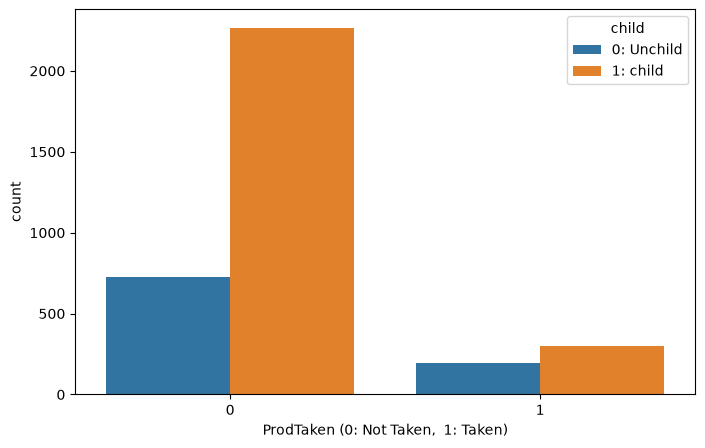

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="ProdTaken", hue="customer_info_child")
plt.xlabel("ProdTaken (0: Not Taken,  1: Taken)")
plt.legend(title="child", labels=["0: Unchild", "1: child"])

plt.show()

# 最終確認

In [19]:
df[["customer_info", "customer_info_marriage","customer_info_usecar","customer_info_child"]]

,customer_info,customer_info_marriage,customer_info_usecar,customer_info_child
0,"[未婚, 車未所持, 子供なし]",0,0,0
1,"[離婚済み, 車あり, 子供無し]",0,1,0
2,"[結婚済み, 自動車未所有, 子供なし]",1,0,0
3,"[離婚済み, 車所持, 子供無し]",0,1,0
4,"[独身, 車所持, 無子]",0,1,0
...,...,...,...,...
3484,"[離婚済み, 乗用車所持, 子供なし]",0,1,0
3485,"[結婚済み, 車所持, 子供2人]",1,1,1
3486,"[独身, 車所持, こども1人]",0,1,1
3487,"[結婚済み, 自動車未所有, 子供2人]",1,0,1
